In [1]:
import rebound
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
from scipy import signal
import heyoka as hy
from celmech import Poincare, PoincareHamiltonian
import symengine as se
import time
import sympy as sp

In [2]:
#constants and helper functions
m_sat = 2.85837e-4
m_jup = 9.945786e-4
m_c = 1

def ft(times, x):
    fs = 1/((times[1] - times[0])/(2*np.pi))
    f, pxx = signal.periodogram(x,fs=fs,window='hann',scaling='density')
    return f,pxx

def pomega_ft(times,pomega,ecc):
    k = ecc*np.cos(pomega)
    h = ecc*np.sin(pomega)*1j
    z = h + k
    f,pxx = ft(times, z)
    return f,pxx

#from celmech docs
def get_pomega(kap,eta):
    return np.arctan2(-eta,kap)

def get_ecc(kap,eta,L):
    P = (kap**2 + eta**2)/2
    return np.sqrt(1 - (1 - P/L)**2)

In [3]:

def hk_integrate(pham,sim_time,num_data_points):
    #H_num = pham.H.subs(dict(pham.H_params))
    H_se = se.sympify(pham.H)
    clean_params_se = {se.sympify(k): v for k, v in dict(pham.H_params).items()
                   if not (hasattr(v, '__float__') and np.isnan(float(v)))}
    H_num = H_se.subs(clean_params_se)
    nan_symbols = {s: 0 for s in H_num.free_symbols 
               if str(s) not in {'Lambda1', 'Lambda2', 'eta1', 'eta2', 
                                  'kappa1', 'kappa2', 'lambda1', 'lambda2',
                                  'rho1', 'rho2', 'sigma1', 'sigma2'}}
    H_num = H_num.subs(nan_symbols)

    
    rho1,rho2,sigma1,sigma2 = se.symbols('rho1 rho2 sigma1 sigma2')
    sym_map = {s: 0 for s in H_num.free_symbols if str(s) in ('rho1', 'rho2', 'sigma1', 'sigma2')}
    H_planar = H_num.subs(sym_map)
    #H_planar = H_num.subs({rho1: 0, rho2: 0, sigma1: 0, sigma2: 0})
    H_planar = se.sympify(H_planar)
    print(sorted(str(s) for s in H_planar.free_symbols))

    lam1,lam2 = se.symbols('lambda1 lambda2')
    Lam1,Lam2 = se.symbols('Lambda1 Lambda2')
    eta1,eta2 = se.symbols('eta1 eta2')
    kap1, kap2 = se.symbols('kappa1 kappa2')

    print('*** Differentiating  ***')

    sym_dict = {str(s): s for s in H_planar.free_symbols}
    lam1 = sym_dict['lambda1']
    lam2 = sym_dict['lambda2']
    Lam1 = sym_dict['Lambda1']
    Lam2 = sym_dict['Lambda2']
    eta1 = sym_dict['eta1']
    eta2 = sym_dict['eta2']
    kap1 = sym_dict['kappa1']
    kap2 = sym_dict['kappa2']

    dLam1_dt = -se.diff(H_planar, lam1)
    dLam2_dt = -se.diff(H_planar, lam2)
    dlam1_dt =  se.diff(H_planar, Lam1)
    dlam2_dt =  se.diff(H_planar, Lam2)

    deta1_dt  = se.diff(H_planar, kap1)
    dkap1_dt  =  -se.diff(H_planar, eta1)
    deta2_dt  = se.diff(H_planar, kap2)
    dkap2_dt  =  -se.diff(H_planar, eta2)

    derivs = [dlam1_dt, dLam1_dt, dlam2_dt, dLam2_dt, deta1_dt, dkap1_dt, deta2_dt, dkap2_dt]

    vars_list = [lam1, Lam1, lam2, Lam2, eta1, kap1, eta2, kap2]
    func = se.Lambdify(vars_list,H_planar)

    jup = pham.state.particles[1]
    sat = pham.state.particles[2]

    initial_conditions = [jup.l, jup.Lambda, sat.l, sat.Lambda,jup.eta, jup.kappa, sat.eta, sat.kappa]
    derivs_at_0 = func(*initial_conditions)

    lam1_hy, Lam1_hy, lam2_hy, Lam2_hy, eta1_hy, kap1_hy, eta2_hy, kap2_hy = hy.make_vars('lam1_hy', 'Lam1_hy', 'lam2_hy', 'Lam2_hy', 'eta1_hy', 'kap1_hy', 'eta2_hy', 'kap2_hy')

    eqs_hy = [hy.from_sympy(sp.sympify(eq), {sp.Symbol('lambda1'): lam1_hy, 
                                          sp.Symbol('Lambda1'): Lam1_hy,
                                          sp.Symbol('lambda2'): lam2_hy, 
                                          sp.Symbol('Lambda2'): Lam2_hy,
                                          sp.Symbol('eta1'): eta1_hy, 
                                          sp.Symbol('kappa1'): kap1_hy,
                                          sp.Symbol('eta2'): eta2_hy, 
                                          sp.Symbol('kappa2'): kap2_hy})
           for eq in derivs]

    ta = hy.taylor_adaptive(sys=[(lam1_hy, eqs_hy[0]),(Lam1_hy, eqs_hy[1]),(lam2_hy, eqs_hy[2]),(Lam2_hy, eqs_hy[3]),(eta1_hy,  eqs_hy[4]),(kap1_hy,  eqs_hy[5]),(eta2_hy,  eqs_hy[6]),(kap2_hy,  eqs_hy[7])],
    state=initial_conditions,
    high_accuracy= True,
    time=0.0,
    tol=1e-16)

    e_i = float(func(*ta.state))
    print(e_i)

    times = np.linspace(0,sim_time,int(num_data_points))*2*np.pi
    e_sat = np.zeros(len(times))
    pomega_sat = np.zeros(len(times))
    e_j = np.zeros(len(times))
    pomega_j = np.zeros(len(times))


    start = time.perf_counter()
    print('*** Starting Simulation ***')
    '''res, min_dt, max_dt, num_steps, callback, flat_states = ta.propagate_grid(times.tolist(), max_delta_t=0.01)

    flat_states = np.array(flat_states)

    num_vars = 8 
    state_matrix = flat_states.reshape(-1, num_vars)

    L_all   = state_matrix[:, 3]
    eta_all = state_matrix[:, 6]
    kap_all = state_matrix[:, 7]

    e_sat = get_ecc(kap_all, eta_all, L_all)
    pomega_sat = get_pomega(kap_all, eta_all)'''
    
    for i in tqdm(range(len(times))):
        ta.propagate_until(times[i],max_delta_t=100.0)
        L, eta, kap = ta.state[3], ta.state[6], ta.state[7]
        Lj, etaj, kapj = ta.state[1], ta.state[4], ta.state[5]
        e_sat[i] = get_ecc(kap, eta, L)
        pomega_sat[i] = get_pomega(kap, eta)
        e_j[i] = get_ecc(kapj, etaj, Lj)
        pomega_j = get_pomega(kapj, etaj)
        
    end = time.perf_counter()

    e_f = float(func(*ta.state))
    print(e_f)
    e_per = (np.abs(e_i - e_f)/np.abs(e_i))*100
    print(f'Energy Percent Change: {e_per} %')
    
    print('*** Simulation Complete ***')

    print('Time elapsed  = ' + str(end-start) + ' seconds')

    return times, pomega_sat, e_sat

## WHFast Plots

Initial Energy: -8.880166633565764e-05
Initital Angular Momentum: <rebound.vectors.Vec3d object at 0x7fed79bfe210, [0.0, 0.0, 0.002352433288717229]>


100%|████████████████████████████████████████████████████████████████████████| 100000/100000 [00:03<00:00, 33198.95it/s]


Final Energy: -8.880166633564625e-05
Energy Percent Change: 1.281971755807761e-11 %
Final Angular Momentum: <rebound.vectors.Vec3d object at 0x7fed79bfe210, [0.0, 0.0, 0.00235243328871738]>
Megno Value: 1.931469101962183


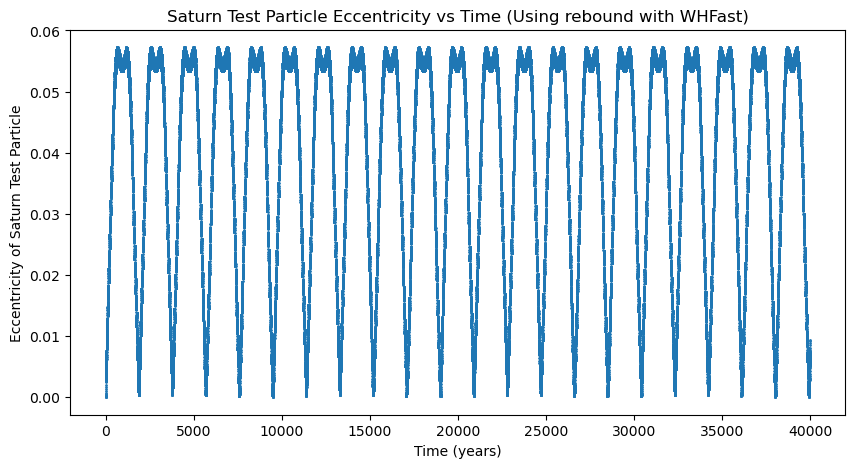

In [5]:
sim = rebound.Simulation()
sim.integrator = "whfast"
sim.dt = 1e-1
sim.add(m=1, hash = "Sun")
sim.add(m=m_jup,a=5.6,e=0,inc = 0,Omega = 0,pomega=np.radians(13.983865),hash="Jupiter")
sim.add(m=1e-10,a=8.9,e=0,inc = 0, Omega = 0,pomega=np.radians(88.719425),hash="Saturn")

sim.move_to_com()

times = np.linspace(0,4e4,int(1e5))*2*np.pi
long_peri_sat = np.zeros(len(times))
e_sat = np.zeros(len(times))
long_peri_j = np.zeros(len(times))
e_j = np.zeros(len(times))
H_energy = np.zeros(len(times))

sim.init_megno()

e_i = sim.energy()
print('Initial Energy: ' + str(e_i))
print('Initital Angular Momentum: ' + str(sim.angular_momentum()))

for i in tqdm(range(len(times))):
    sim.integrate(times[i])
    long_peri_sat[i] = sim.particles[2].pomega
    e_sat[i] = sim.particles[2].e
    H_energy[i] = sim.energy()
    

e_f = sim.energy()
print('Final Energy: ' + str(e_f))
e_per = (np.abs(e_i - e_f)/np.abs(e_i))*100
print(f'Energy Percent Change: {e_per} %')
print('Final Angular Momentum: ' + str(sim.angular_momentum()))
print('Megno Value: ' + str(sim.megno()))

plt.figure(figsize=(10, 5))
plt.scatter(times/(2*np.pi), e_sat,s=1)
plt.ylabel('Eccentricity of Saturn Test Particle')
plt.xlabel("Time (years)")
plt.title('Saturn Test Particle Eccentricity vs Time (Using rebound with WHFast)')
plt.show()

Initial Energy: -8.880166633565764e-05
Initital Angular Momentum: <rebound.vectors.Vec3d object at 0x7fed7f7ea030, [0.0, 0.0, 0.002352433288717229]>


100%|██████████████████████████████████████████████████████████████████████████| 100000/100000 [08:36<00:00, 193.59it/s]


Final Energy: -8.880166633550319e-05
Final Angular Momentum: <rebound.vectors.Vec3d object at 0x7fed7f7ea250, [0.0, 0.0, 0.0023524332887192747]>
Megno Value: 2.000169088208057


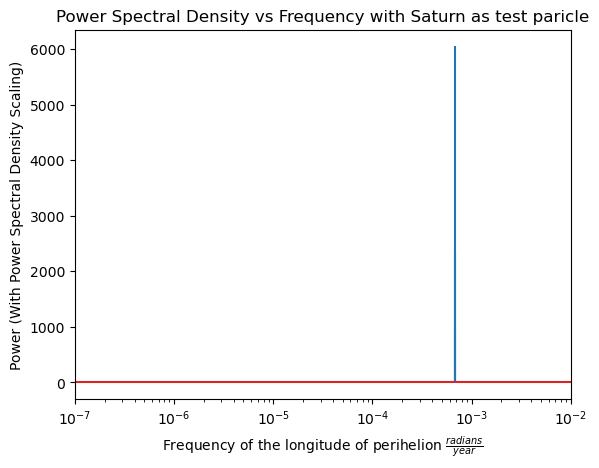

In [13]:
sim = rebound.Simulation()
sim.integrator = "whfast"
sim.dt = 1e-1
sim.add(m=1, hash = "Sun")
sim.add(m=m_jup,a=5.6,e=0,inc = 0,Omega = 0,pomega=np.radians(13.983865),hash="Jupiter")
sim.add(m=1e-10,a=8.9,e=0,inc = 0, Omega = 0,pomega=np.radians(88.719425),hash="Saturn")

sim.move_to_com()

times = np.linspace(0, 1e7, int(1e5)) * 2 * np.pi
long_peri_sat = np.zeros(len(times))
e_sat = np.zeros(len(times))
long_peri_j = np.zeros(len(times))
e_j = np.zeros(len(times))

print('Initial Energy: ' + str(sim.energy()))
print('Initital Angular Momentum: ' + str(sim.angular_momentum()))

sim.init_megno()

for i in tqdm(range(len(times))):
    sim.integrate(times[i])
    long_peri_sat[i] = sim.particles[2].pomega
    e_sat[i] = sim.particles[2].e
    long_peri_j[i] = sim.particles[1].pomega
    e_j[i] = sim.particles[1].e

print('Final Energy: ' + str(sim.energy()))
print('Final Angular Momentum: ' + str(sim.angular_momentum()))
print('Megno Value: ' + str(sim.megno()))
#print('Lyapunov characteristic number: ' + str(sim.lyapunov()))

f,pxx = pomega_ft(times, long_peri_sat, e_sat)
plt.stem(f*2*np.pi,pxx,markerfmt = "none",label = 'Frequencies found through simulation')
plt.xscale('log')
plt.ylabel('Power (With Power Spectral Density Scaling)')
plt.xlabel(r"Frequency of the longitude of perihelion $\frac{radians}{year}$")
plt.xlim(1e-7,1e-2)
plt.title(r'Power Spectral Density vs Frequency with Saturn as test paricle')
plt.show()

# Heyoka Plots

['Lambda1', 'Lambda2', 'eta1', 'eta2', 'kappa1', 'kappa2', 'lambda1', 'lambda2']
*** Differentiating  ***
-8.880166632853778e-05
*** Starting Simulation ***


100%|███████████████████████████████████████████████████████████████████████| 100000/100000 [00:00<00:00, 116752.03it/s]


-8.880166632853774e-05
Energy Percent Change: 4.578470556823378e-14 %
*** Simulation Complete ***
Time elapsed  = 0.8585491009998805 seconds


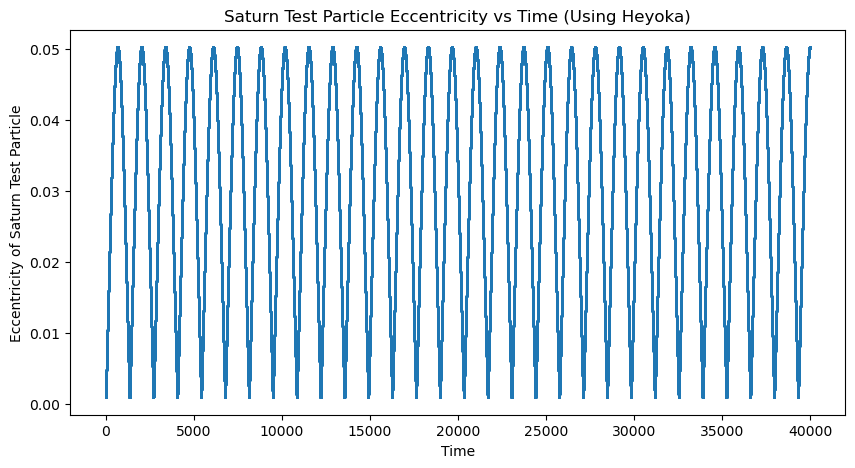

In [7]:
sim = rebound.Simulation()
sim.add(m=1, hash = "Sun")
sim.add(m=m_jup,a=5.6,e=0,inc = 0,Omega = 0,pomega=np.radians(13.983865),hash="Jupiter")
sim.add(m=1e-10,a=8.9,e=0,inc = 0, Omega = 0,pomega=np.radians(88.719425),hash="Saturn")

sim.move_to_com()

pvars = Poincare.from_Simulation(sim)

pham = PoincareHamiltonian(pvars)
pham.add_secular_terms(indexIn=1, indexOut=2, max_order=2)
pham.add_MMR_terms(p=2,q=1,indexIn=1, indexOut=2, max_order=1)

times, pomega_sat, e_sat = hk_integrate(pham,4e4,1e5)

plt.figure(figsize=(10, 5))
plt.scatter(times/(2*np.pi), e_sat,s=1)
plt.ylabel('Eccentricity of Saturn Test Particle')
plt.xlabel("Time")
plt.title('Saturn Test Particle Eccentricity vs Time (Using Heyoka)')
plt.show()

['Lambda1', 'Lambda2', 'eta1', 'eta2', 'kappa1', 'kappa2', 'lambda1', 'lambda2']
*** Differentiating  ***
-8.880166632853776e-05
*** Starting Simulation ***


100%|████████████████████████████████████████████████████████████████████████| 100000/100000 [00:01<00:00, 77709.60it/s]


-8.880166632853923e-05
Energy Percent Change: 1.6482494004564161e-12 %
*** Simulation Complete ***
Time elapsed  = 1.2896174300003622 seconds


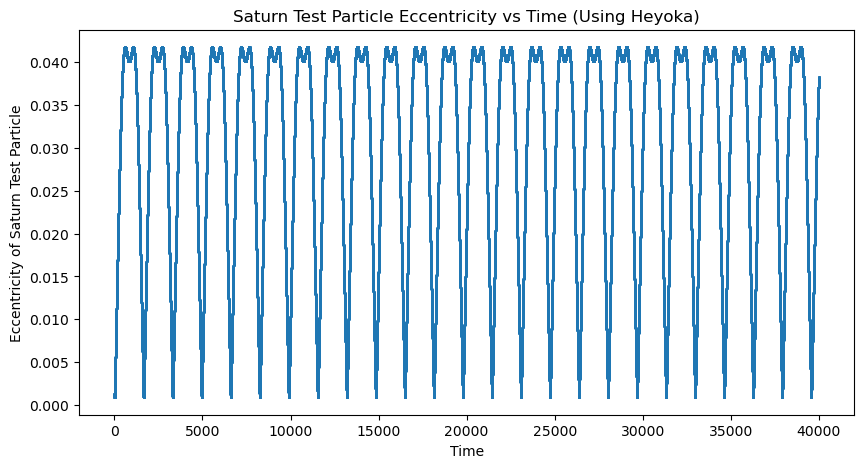

In [8]:
sim = rebound.Simulation()
sim.add(m=1, hash = "Sun")
sim.add(m=m_jup,a=5.6,e=0,inc = 0,Omega = 0,pomega=np.radians(13.983865),hash="Jupiter")
sim.add(m=1e-10,a=8.9,e=0,inc = 0, Omega = 0,pomega=np.radians(88.719425),hash="Saturn")

sim.move_to_com()

pvars = Poincare.from_Simulation(sim)

pham = PoincareHamiltonian(pvars)
pham.add_secular_terms(indexIn=1, indexOut=2, max_order=4)
pham.add_MMR_terms(p=2,q=1,indexIn=1, indexOut=2, max_order=2)

times, pomega_sat, e_sat = hk_integrate(pham,4e4,1e5)

plt.figure(figsize=(10, 5))
plt.scatter(times/(2*np.pi), e_sat,s=1)
plt.ylabel('Eccentricity of Saturn Test Particle')
plt.xlabel("Time")
plt.title('Saturn Test Particle Eccentricity vs Time (Using Heyoka)')
plt.show()

In [9]:
sim = rebound.Simulation()
sim.add(m=1, hash = "Sun")
sim.add(m=m_jup,a=5.6,e=0,inc = 0,Omega = 0,pomega=np.radians(13.983865),hash="Jupiter")
sim.add(m=1e-10,a=8.9,e=0,inc = 0, Omega = 0,pomega=np.radians(88.719425),hash="Saturn")

sim.move_to_com()

pvars = Poincare.from_Simulation(sim)

pham = PoincareHamiltonian(pvars)
pham.add_secular_terms(indexIn=1, indexOut=2, max_order=2)
pham.add_MMR_terms(p=2,q=1,indexIn=1, indexOut=2, max_order=1)

times, pomega_sat, e_sat = hk_integrate(pham,1e7,1e5)

['Lambda1', 'Lambda2', 'eta1', 'eta2', 'kappa1', 'kappa2', 'lambda1', 'lambda2']
*** Differentiating  ***
-8.880166632853778e-05
*** Starting Simulation ***


100%|████████████████████████████████████████████████████████████████████████| 100000/100000 [00:01<00:00, 70087.57it/s]

-8.880166632852693e-05
Energy Percent Change: 1.2209254818195675e-11 %
*** Simulation Complete ***
Time elapsed  = 1.4290305630001967 seconds


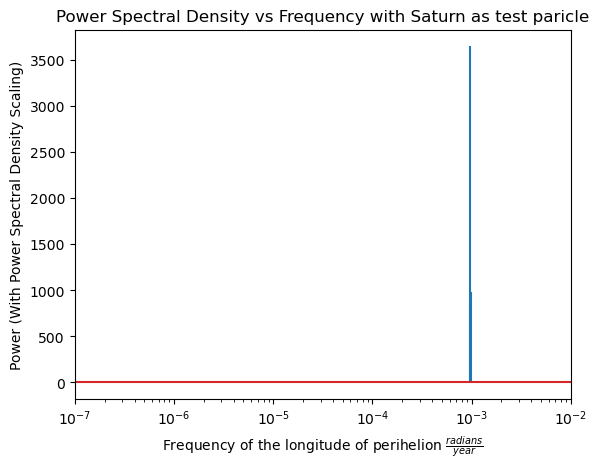

In [10]:
f,pxx = pomega_ft(times, pomega_sat, e_sat)
plt.stem(f*2*np.pi,pxx,markerfmt = "none",label = 'Frequencies found through simulation')
plt.xscale('log')
plt.ylabel('Power (With Power Spectral Density Scaling)')
plt.xlabel(r"Frequency of the longitude of perihelion $\frac{radians}{year}$")
plt.xlim(1e-7,1e-2)
plt.title(r'Power Spectral Density vs Frequency with Saturn as test paricle')
plt.show()

['Lambda1', 'Lambda2', 'eta1', 'eta2', 'kappa1', 'kappa2', 'lambda1', 'lambda2']
*** Differentiating  ***
-8.880166632853776e-05
*** Starting Simulation ***


100%|█████████████████████████████████████████████████████████████████████████████████████| 100000/100000 [00:07<00:00, 13465.19it/s]


-8.880166632852662e-05
Energy Percent Change: 1.2545009325696058e-11 %
*** Simulation Complete ***
Time elapsed  = 4.482751896000082 seconds


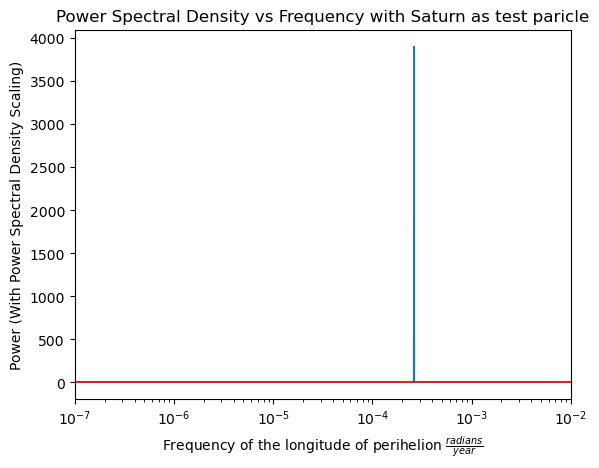

In [25]:
sim = rebound.Simulation()
sim.add(m=1, hash = "Sun")
sim.add(m=m_jup,a=5.6,e=0,inc = 0,Omega = 0,pomega=np.radians(13.983865),hash="Jupiter")
sim.add(m=1e-10,a=8.9,e=0,inc = 0, Omega = 0,pomega=np.radians(88.719425),hash="Saturn")

sim.move_to_com()

pvars = Poincare.from_Simulation(sim)

pham = PoincareHamiltonian(pvars)
pham.add_secular_terms(indexIn=1, indexOut=2, max_order=4)
pham.add_MMR_terms(p=2,q=1,indexIn=1, indexOut=2, max_order=2)

times, pomega_sat, e_sat = hk_integrate(pham,1e7,1e5)

f,pxx = pomega_ft(times, pomega_sat, e_sat)
plt.stem(f*2*np.pi,pxx,markerfmt = "none",label = 'Frequencies found through simulation')
plt.xscale('log')
plt.ylabel('Power (With Power Spectral Density Scaling)')
plt.xlabel(r"Frequency of the longitude of perihelion $\frac{radians}{year}$")
plt.xlim(1e-7,1e-2)
plt.title(r'Power Spectral Density vs Frequency with Saturn as test paricle')
plt.show()

# Celmech Plots

Initial Energy: " -8.880166632853771e-05


100%|██████████████████████████████████████████████████████████████████████████████████████| 100000/100000 [00:49<00:00, 2024.36it/s]


Final Energy: " -8.88016663285448e-05
Energy Percent Change: 7.981800337395428e-12 %


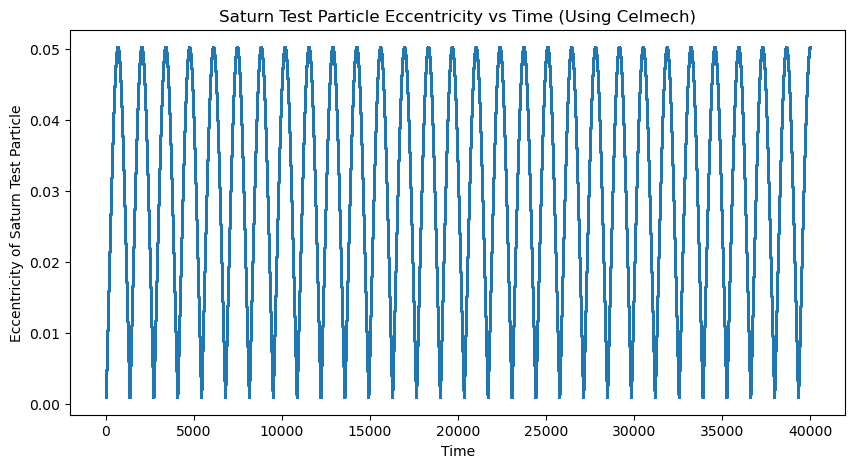

In [11]:
sim = rebound.Simulation()
sim.add(m=1, hash = "Sun")
sim.add(m=m_jup,a=5.6,e=0,inc = 0,Omega = 0,pomega=np.radians(13.983865),hash="Jupiter")
sim.add(m=1e-10,a=8.9,e=0,inc = 0, Omega = 0,pomega=np.radians(88.719425),hash="Saturn")

sim.move_to_com()

times = np.linspace(0,4e4,int(1e5))*2*np.pi
long_peri_sat = np.zeros(len(times))
e_sat = np.zeros(len(times))
long_peri_j = np.zeros(len(times))
e_j = np.zeros(len(times))

pvars = Poincare.from_Simulation(sim)

pham = PoincareHamiltonian(pvars)
pham.add_secular_terms(indexIn=1, indexOut=2,l_max = 0, max_order=2)
pham.add_MMR_terms(p=2,q=1,indexIn=1, indexOut=2,l_max = 0, max_order=1)

e_i = pham.calculate_energy()
print('Initial Energy: '+ str(e_i))

for i in tqdm(range(len(times))):
    pham.integrate(times[i])
    long_peri_sat[i] = pham.state.particles[2].pomega
    e_sat[i] = pham.state.particles[2].e
    
e_f = pham.calculate_energy()
print('Final Energy: '+ str(e_f))
e_per = (np.abs(e_i - e_f)/np.abs(e_i))*100 
print(f'Energy Percent Change: {e_per} %')
plt.figure(figsize=(10, 5))
plt.scatter(times/(2*np.pi), e_sat,s=1)
plt.ylabel('Eccentricity of Saturn Test Particle')
plt.xlabel("Time")
plt.title('Saturn Test Particle Eccentricity vs Time (Using Celmech)')
plt.show()

Initial Energy: " -8.880166632853771e-05


100%|██████████████████████████████████████████████████████████████████████████████████████| 100000/100000 [01:27<00:00, 1137.31it/s]


Final Energy: " -8.880166632867073e-05
Energy Percent Change: 1.497922950507383e-10 %


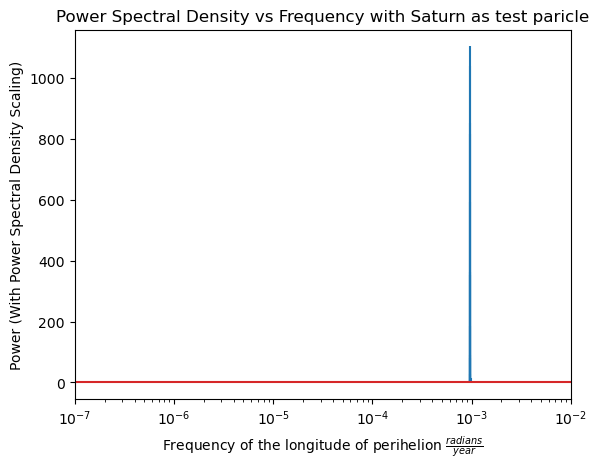

In [21]:
sim = rebound.Simulation()
sim.add(m=1, hash = "Sun")
sim.add(m=m_jup,a=5.6,e=0,inc = 0,Omega = 0,pomega=np.radians(13.983865),hash="Jupiter")
sim.add(m=1e-10,a=8.9,e=0,inc = 0, Omega = 0,pomega=np.radians(88.719425),hash="Saturn")

sim.move_to_com()

times = np.linspace(0,1e7,int(1e5))*2*np.pi
long_peri_sat = np.zeros(len(times))
e_sat = np.zeros(len(times))
long_peri_j = np.zeros(len(times))
e_j = np.zeros(len(times))

pvars = Poincare.from_Simulation(sim)

pham = PoincareHamiltonian(pvars)
pham.add_secular_terms(indexIn=1, indexOut=2,l_max = 0, max_order=2)
pham.add_MMR_terms(p=2,q=1,indexIn=1, indexOut=2,l_max = 0, max_order=1)

e_i = pham.calculate_energy()
print('Initial Energy: " '+ str(e_i))

for i in tqdm(range(len(times))):
    pham.integrate(times[i])
    long_peri_sat[i] = pham.state.particles[2].pomega
    e_sat[i] = pham.state.particles[2].e
    
e_f = pham.calculate_energy()
print('Final Energy: " '+ str(e_f))
e_per = (np.abs(e_i - e_f)/np.abs(e_i))*100 
print(f'Energy Percent Change: {e_per} %')
f,pxx = pomega_ft(times, long_peri_sat, e_sat)
plt.stem(f*2*np.pi,pxx,markerfmt = "none",label = 'Frequencies found through simulation')
plt.xscale('log')
plt.ylabel('Power (With Power Spectral Density Scaling)')
plt.xlabel(r"Frequency of the longitude of perihelion $\frac{radians}{year}$")
plt.xlim(1e-7,1e-2)
plt.title(r'Power Spectral Density vs Frequency with Saturn as test paricle')
plt.show()